In [2]:
# === 1) Імпорти та фіксація seed ===
import re, time, random, numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
# === 2) Завантаження Fake.csv / True.csv ===
FAKE_PATH = "Data/Fake.csv"
TRUE_PATH = "Data/True.csv"

fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)

fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Візьмемо Title + Text (можна замінити на лише Text)
df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).astype(str)

df[["content","label"]].head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,0


In [5]:
# === 3) Мінімальне очищення тексту (lowercase + прибрати зайві символи) ===
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)           # лінки
    text = re.sub(r"[^a-z0-9\s']", " ", text)             # залишаємо букви/цифри/пробіли
    text = re.sub(r"\s{2,}", " ", text).strip()
    return text

df["content"] = df["content"].apply(clean_text)
df["content"].head()

0    ben stein calls out 9th circuit court committe...
1    trump drops steve bannon from national securit...
2    puerto rico expects u s to lift jones act ship...
3    oops trump just accidentally confirmed he leak...
4    donald trump heads for scotland to reopen a go...
Name: content, dtype: object

In [6]:
# === 4) Токенізація + словник ===
def tokenize(text: str):
    return text.split()

# рахуємо частоти
counter = Counter()
for t in df["content"]:
    counter.update(tokenize(t))

VOCAB_SIZE = 30000  # top-k слів
most_common = counter.most_common(VOCAB_SIZE-2)

itos = ["<PAD>", "<UNK>"] + [w for w, _ in most_common]
stoi = {w:i for i,w in enumerate(itos)}

PAD_IDX = stoi["<PAD>"]
UNK_IDX = stoi["<UNK>"]

def numericalize(tokens):
    return [stoi.get(tok, UNK_IDX) for tok in tokens]

len(itos), itos[:10]

(30000, ['<PAD>', '<UNK>', 'the', 'to', 'of', 'a', 'and', 'in', 's', 'that'])

In [7]:
# === 5) Перетворення у індекси + padding/truncation ===
MAX_LEN = 250

def encode(text: str, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = numericalize(tokens)[:max_len]
    if len(ids) < max_len:
        ids = ids + [PAD_IDX]*(max_len-len(ids))
    return ids

df["ids"] = df["content"].apply(encode)
df["ids"].iloc[0][:15], len(df["ids"].iloc[0])

([1793, 2982, 613, 56, 5145, 2443, 130, 1166, 5, 2039, 307, 13058, 91, 2, 939],
 250)

In [8]:
# === 6) Train/Val/Test split 80/10/10 ===
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

len(train_df), len(val_df), len(test_df)

(35918, 4490, 4490)

In [9]:
# === 7) Dataset/DataLoader ===
class NewsDataset(Dataset):
    def __init__(self, frame):
        self.X = frame["ids"].tolist()
        self.y = frame["label"].tolist()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

BATCH_SIZE = 64

train_loader = DataLoader(NewsDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NewsDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NewsDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

---

## 3. Моделі

### 3.1 Simple RNN classifier
Реалізація відповідає скелету з методички: Embedding → RNN → FC → Sigmoid.

### 3.2 LSTM classifier
Embedding → LSTM (може бути bidirectional) → FC → Sigmoid.

In [10]:
# === 8) Simple RNN Classifier ===
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)              # (B, L, emb_dim)
        out, h_n = self.rnn(emb)             # h_n: (layers, B, H)
        last = h_n[-1]                       # (B, H)
        logits = self.fc(last).squeeze(1)    # (B,)
        prob = torch.sigmoid(logits)
        return prob, logits

# === 9) LSTM Classifier ===
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
        self.bidirectional = bidirectional

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        if self.bidirectional:
            # concat forward + backward last states
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        prob = torch.sigmoid(logits)
        return prob, logits

---

## 4. Навчання та валідація

Використовуємо:
- `BCEWithLogitsLoss()` (бо працюємо з логітами)
- `Adam`
- gradient clipping `clip_grad_norm_` для стабільності

In [11]:
# === 10) Training / Validation loops ===
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    all_probs, all_labels = [], []
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        if train_mode:
            optimizer.zero_grad()

        probs, logits = model(x_batch)
        loss = criterion(logits, y_batch)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        all_probs.append(probs.detach().cpu())
        all_labels.append(y_batch.detach().cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)
    f1  = f1_score(all_labels, preds)
    return total_loss / len(loader.dataset), acc, f1, all_probs, all_labels

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[], "train_acc":[], "val_acc":[]}

    for ep in range(1, epochs+1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader, criterion, None)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(va_f1)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        print(f"Epoch {ep:02d}: "
              f"train loss={tr_loss:.4f}, f1={tr_f1:.4f}, acc={tr_acc:.4f} | "
              f"val loss={va_loss:.4f}, f1={va_f1:.4f}, acc={va_acc:.4f}")
    return history

In [12]:
# === 11) Базове навчання двох моделей ===
BASE_CFG = dict(
    vocab_size=len(itos),
    emb_dim=100,
    hidden_dim=128,
    num_layers=1,
    dropout=0.2
)

rnn_model = SimpleRNNClassifier(**BASE_CFG)
lstm_model = LSTMClassifier(**BASE_CFG, bidirectional=False)

print("Training RNN...")
hist_rnn = train_model(rnn_model, train_loader, val_loader, epochs=5, lr=1e-3)

print("\nTraining LSTM...")
hist_lstm = train_model(lstm_model, train_loader, val_loader, epochs=5, lr=1e-3)

Training RNN...
Epoch 01: train loss=0.6514, f1=0.6740, acc=0.6222 | val loss=0.5327, f1=0.7955, acc=0.7759
Epoch 02: train loss=0.5695, f1=0.7590, acc=0.7236 | val loss=0.6344, f1=0.7077, acc=0.6688
Epoch 03: train loss=0.5172, f1=0.7943, acc=0.7694 | val loss=0.4830, f1=0.8063, acc=0.8076
Epoch 04: train loss=0.4587, f1=0.8219, acc=0.8115 | val loss=0.4368, f1=0.8426, acc=0.8392
Epoch 05: train loss=0.4258, f1=0.8366, acc=0.8286 | val loss=0.4106, f1=0.8225, acc=0.8178

Training LSTM...
Epoch 01: train loss=0.5732, f1=0.7358, acc=0.7194 | val loss=0.6750, f1=0.5975, acc=0.5699
Epoch 02: train loss=0.4766, f1=0.8036, acc=0.7845 | val loss=0.2829, f1=0.9013, acc=0.9022
Epoch 03: train loss=0.0788, f1=0.9782, acc=0.9772 | val loss=0.0369, f1=0.9877, acc=0.9873
Epoch 04: train loss=0.0163, f1=0.9964, acc=0.9962 | val loss=0.0116, f1=0.9970, acc=0.9969
Epoch 05: train loss=0.0080, f1=0.9985, acc=0.9984 | val loss=0.0087, f1=0.9979, acc=0.9978


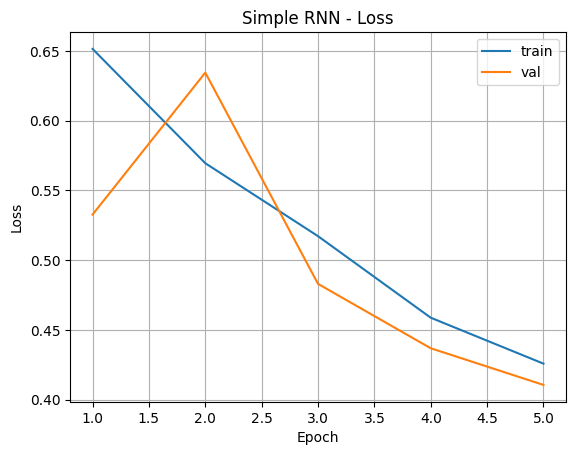

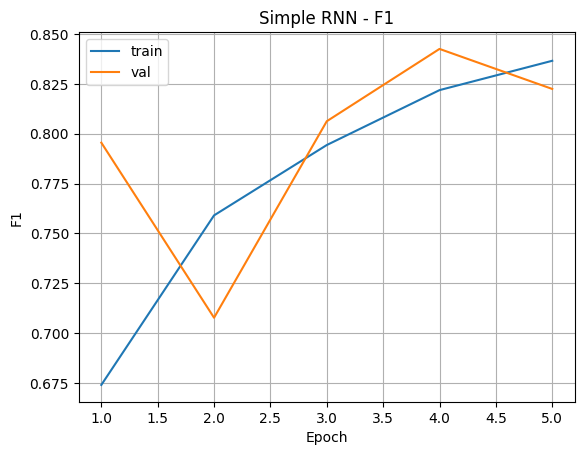

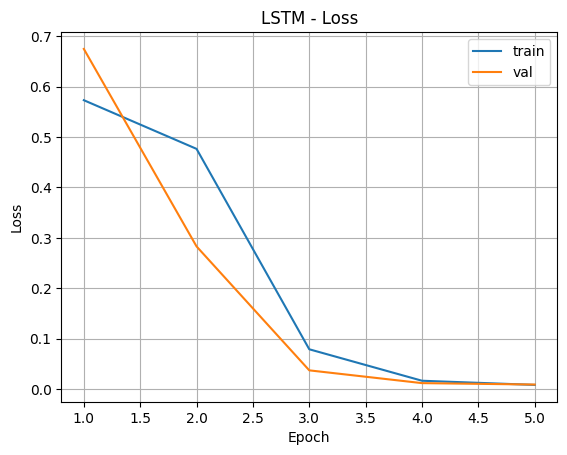

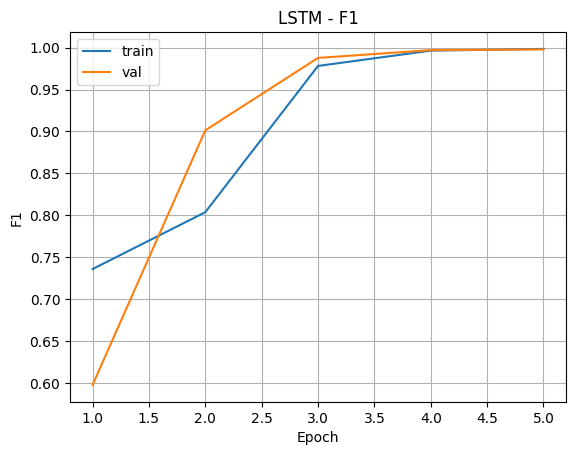

In [13]:
# === 12) Графіки train/val loss і F1 (вимога методички) ===
def plot_history(hist, title):
    epochs = range(1, len(hist["train_loss"])+1)

    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="train")
    plt.plot(epochs, hist["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["train_f1"], label="train")
    plt.plot(epochs, hist["val_f1"], label="val")
    plt.title(f"{title} - F1")
    plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend(); plt.grid(True)
    plt.show()

plot_history(hist_rnn, "Simple RNN")
plot_history(hist_lstm, "LSTM")

In [14]:
# === 13) Оцінка на тесті + Confusion Matrix + ROC ===
def evaluate_on_test(model, loader):
    criterion = nn.BCEWithLogitsLoss()
    loss, acc, f1, probs, labels = run_epoch(model, loader, criterion, None)
    preds = (probs >= 0.5).astype(int)

    prec = precision_score(labels, preds)
    rec  = recall_score(labels, preds)
    auc  = roc_auc_score(labels, probs)

    return {
        "loss": loss, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc,
        "probs": probs, "labels": labels, "preds": preds
    }

res_rnn  = evaluate_on_test(rnn_model, test_loader)
res_lstm = evaluate_on_test(lstm_model, test_loader)

res_rnn, res_lstm

({'loss': 0.44649439916047856,
  'acc': 0.7946547884187083,
  'prec': 0.8185880250223414,
  'rec': 0.7802385008517888,
  'f1': 0.7989533362407326,
  'auc': 0.8753099763471544,
  'probs': array([0.96082616, 0.6683287 , 0.03382663, ..., 0.03382663, 0.7564693 ,
         0.3372707 ], shape=(4490,), dtype=float32),
  'labels': array([1., 0., 0., ..., 0., 1., 0.], shape=(4490,), dtype=float32),
  'preds': array([1, 1, 0, ..., 0, 1, 0], shape=(4490,))},
 {'loss': 0.016115244520534627,
  'acc': 0.9973273942093541,
  'prec': 0.9978687127024722,
  'rec': 0.9970187393526405,
  'f1': 0.9974435449510013,
  'auc': 0.9992283398311056,
  'probs': array([9.9949443e-01, 7.8683143e-04, 7.0331665e-04, ..., 6.5573538e-04,
         9.9889117e-01, 8.9466723e-04], shape=(4490,), dtype=float32),
  'labels': array([1., 0., 0., ..., 0., 1., 0.], shape=(4490,), dtype=float32),
  'preds': array([1, 0, 0, ..., 0, 1, 0], shape=(4490,))})

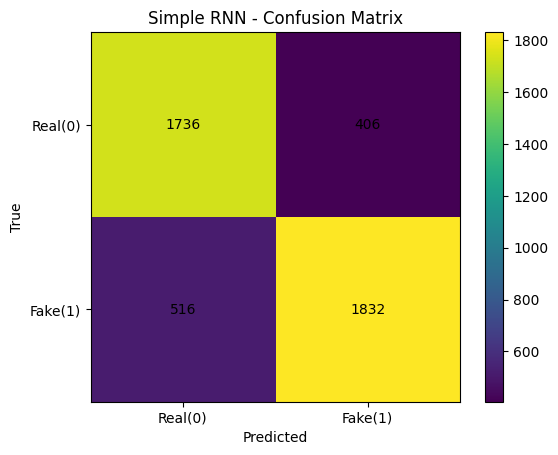

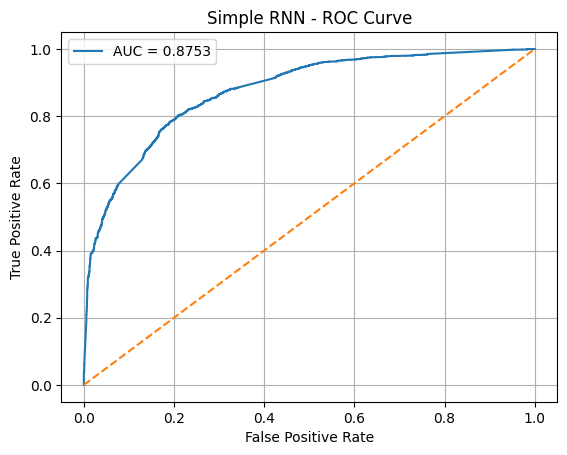

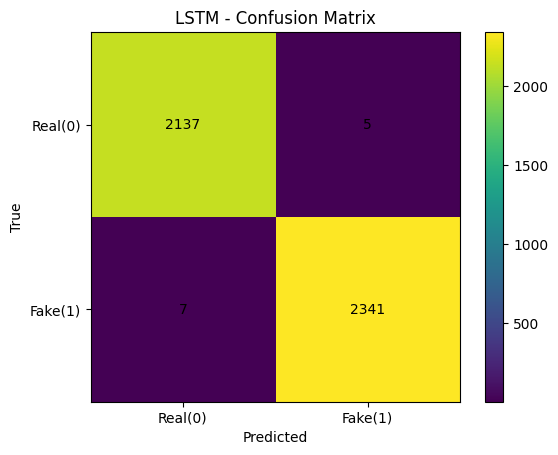

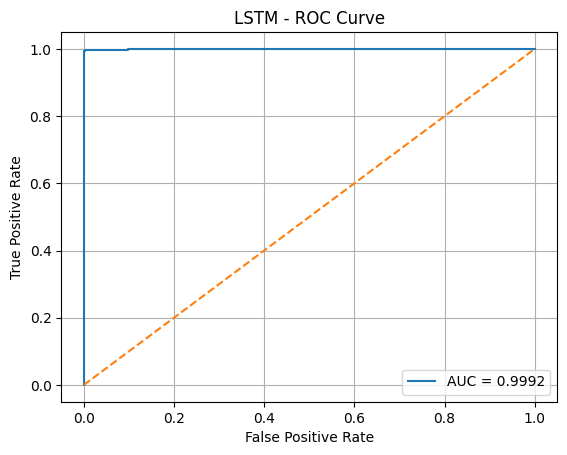

In [15]:
def plot_confusion_and_roc(res, title):
    labels, preds, probs = res["labels"], res["preds"], res["probs"]

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} - Confusion Matrix")
    plt.colorbar()
    plt.xticks([0,1], ["Real(0)", "Fake(1)"])
    plt.yticks([0,1], ["Real(0)", "Fake(1)"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {res['auc']:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{title} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(); plt.grid(True)
    plt.show()

plot_confusion_and_roc(res_rnn, "Simple RNN")
plot_confusion_and_roc(res_lstm, "LSTM")

## ФУНКЦІЇ ДЛЯ ГІПЕРПАРАМЕТРІВ

In [ ]:
def count_params(model):
    """Підрахунок кількості параметрів моделі"""
    return sum(p.numel() for p in model.parameters())

def train_config(model_cls, cfg, epochs=3):
    """Тренування моделі з конкретною конфігурацією"""
    set_seed(42)
    
    # Витягуємо lr з конфігурації (не передаємо в модель)
    lr = cfg.pop("lr", 1e-3)
    
    # Створюємо модель без lr
    model = model_cls(**cfg).to(device)
    
    start = time.time()
    hist = train_model(model, train_loader, val_loader, epochs=epochs, lr=lr)
    epoch_time = (time.time() - start) / epochs

    res = evaluate_on_test(model, test_loader)
    
    # Повертаємо lr назад в cfg для наступних використань
    cfg["lr"] = lr
    
    return {
        "model": model_cls.__name__,
        "emb_dim": cfg["emb_dim"],
        "hidden_dim": cfg["hidden_dim"],
        "layers": cfg["num_layers"],
        "bidirectional": cfg.get("bidirectional", False),
        "dropout": cfg["dropout"],
        "lr": lr,
        "params": count_params(model),
        "f1": res["f1"],
        "auc": res["auc"],
        "accuracy": res.get("accuracy", 0),  # На випадок, якщо accuracy немає
        "epoch_time": epoch_time
    }

grid = [
    dict(vocab_size=len(itos), emb_dim=50,  hidden_dim=64,  num_layers=1, dropout=0.2, lr=1e-3),
    dict(vocab_size=len(itos), emb_dim=100, hidden_dim=128, num_layers=1, dropout=0.2, lr=1e-3),
    dict(vocab_size=len(itos), emb_dim=200, hidden_dim=256, num_layers=2, dropout=0.5, lr=5e-4),
]


print("HYPERPARAMETER SEARCH")
print("="*70)
print(f"Тестуємо {len(grid) * 3} конфігурацій...\n")

results = []
for i, cfg in enumerate(grid, 1):
    print(f"Configuration {i}/{len(grid)}:")
    print(f"  emb_dim={cfg['emb_dim']}, hidden_dim={cfg['hidden_dim']}, layers={cfg['num_layers']}")
    
    print("  → SimpleRNN...")
    results.append(train_config(SimpleRNNClassifier, cfg, epochs=3))
    
    print("  → LSTM (unidirectional)...")
    results.append(train_config(LSTMClassifier, {**cfg, "bidirectional": False}, epochs=3))
    
    print("  → LSTM (bidirectional)...")
    results.append(train_config(LSTMClassifier, {**cfg, "bidirectional": True}, epochs=3))
    print()

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)

# Додаємо комбіновану назву моделі
results_df['model_name'] = results_df.apply(
    lambda x: f"{x['model']}" + (" (Bi)" if x['bidirectional'] else ""),
    axis=1
)

HYPERPARAMETER SEARCH
Тестуємо 9 конфігурацій...

Configuration 1/3:
  emb_dim=50, hidden_dim=64, layers=1
  → SimpleRNN...
Epoch 01: train loss=0.6727, f1=0.6214, acc=0.5840 | val loss=0.6570, f1=0.6911, acc=0.6265
Epoch 02: train loss=0.6010, f1=0.7308, acc=0.7004 | val loss=0.5429, f1=0.7522, acc=0.7592
Epoch 03: train loss=0.5217, f1=0.7815, acc=0.7709 | val loss=0.5090, f1=0.8064, acc=0.7931
  → LSTM (unidirectional)...
Epoch 01: train loss=0.6126, f1=0.6647, acc=0.6691 | val loss=0.4798, f1=0.8070, acc=0.8073
Epoch 02: train loss=0.5106, f1=0.7839, acc=0.7822 | val loss=0.4742, f1=0.8451, acc=0.8203
Epoch 03: train loss=0.4137, f1=0.8630, acc=0.8480 | val loss=0.3429, f1=0.8931, acc=0.8797
  → LSTM (bidirectional)...
Epoch 01: train loss=0.1205, f1=0.9545, acc=0.9519 | val loss=0.0152, f1=0.9981, acc=0.9980
Epoch 02: train loss=0.0098, f1=0.9986, acc=0.9985 | val loss=0.0145, f1=0.9977, acc=0.9976
Epoch 03: train loss=0.0075, f1=0.9987, acc=0.9987 | val loss=0.0111, f1=0.9981, ac

# 1. ТОП-10 МОДЕЛЕЙ ЗА F1-SCORE

In [ ]:
print("\n" + "="*70)
print("ТОП-10 МОДЕЛЕЙ ЗА F1-SCORE")
print("="*70)
print(results_df.head(10).to_string(index=False))

# 2. ВІЗУАЛІЗАЦІЯ: OVERVIEW ВСІХ МЕТРИК

In [ ]:
def plot_comprehensive_comparison(df):
    """Комплексне порівняння всіх моделей"""
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. F1-Score по моделях
    ax1 = fig.add_subplot(gs[0, :2])
    df_sorted = df.sort_values('f1', ascending=True)
    colors = ['#3498db' if 'SimpleRNN' in m else '#e74c3c' if 'Bi' in m else '#f39c12' 
              for m in df_sorted['model_name']]
    
    bars = ax1.barh(range(len(df_sorted)), df_sorted['f1'], color=colors, alpha=0.8, edgecolor='black')
    ax1.set_yticks(range(len(df_sorted)))
    ax1.set_yticklabels([f"{m}\n{e}d-{h}d-{l}L" for m, e, h, l in 
                         zip(df_sorted['model_name'], df_sorted['emb_dim'], 
                             df_sorted['hidden_dim'], df_sorted['layers'])], fontsize=8)
    ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
    ax1.set_title('F1-Score Comparison (All Configurations)', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Додаємо значення на барах
    for i, (bar, val) in enumerate(zip(bars, df_sorted['f1'])):
        ax1.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=8)
    
    # 2. Performance vs Parameters Trade-off
    ax2 = fig.add_subplot(gs[0, 2])
    scatter = ax2.scatter(df['params']/1000, df['f1'], 
                         c=df['epoch_time'], s=100, alpha=0.7, 
                         cmap='viridis', edgecolors='black', linewidth=1)
    
    for idx, row in df.iterrows():
        if row['f1'] > df['f1'].quantile(0.75):  # Анотуємо топ 25%
            ax2.annotate(row['model_name'][:8], 
                        (row['params']/1000, row['f1']),
                        fontsize=7, alpha=0.7)
    
    ax2.set_xlabel('Parameters (thousands)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax2.set_title('Efficiency vs Performance', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Training Time (s/epoch)', fontsize=9)
    
    # 3. F1 vs AUC корреляція
    ax3 = fig.add_subplot(gs[1, 0])
    for model_type in df['model'].unique():
        mask = df['model'] == model_type
        ax3.scatter(df[mask]['auc'], df[mask]['f1'], 
                   label=model_type, s=80, alpha=0.7, edgecolors='black', linewidth=1)
    
    ax3.plot([0.5, 1], [0.5, 1], 'k--', alpha=0.3, label='Perfect correlation')
    ax3.set_xlabel('AUC', fontsize=11, fontweight='bold')
    ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax3.set_title('F1 vs AUC Correlation', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Embedding Dimension Impact
    ax4 = fig.add_subplot(gs[1, 1])
    emb_groups = df.groupby('emb_dim').agg({'f1': ['mean', 'std']}).reset_index()
    emb_groups.columns = ['emb_dim', 'f1_mean', 'f1_std']
    
    ax4.bar(emb_groups['emb_dim'].astype(str), emb_groups['f1_mean'], 
           yerr=emb_groups['f1_std'], capsize=5, alpha=0.8, 
           color='#3498db', edgecolor='black', linewidth=1.5)
    ax4.set_xlabel('Embedding Dimension', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Mean F1-Score', fontsize=11, fontweight='bold')
    ax4.set_title('Impact of Embedding Dimension', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    # Додаємо значення
    for i, (x, y) in enumerate(zip(emb_groups['emb_dim'].astype(str), emb_groups['f1_mean'])):
        ax4.text(i, y + 0.01, f'{y:.4f}', ha='center', fontsize=9, fontweight='bold')
    
    # 5. Hidden Dimension Impact
    ax5 = fig.add_subplot(gs[1, 2])
    hidden_groups = df.groupby('hidden_dim').agg({'f1': ['mean', 'std']}).reset_index()
    hidden_groups.columns = ['hidden_dim', 'f1_mean', 'f1_std']
    
    ax5.bar(hidden_groups['hidden_dim'].astype(str), hidden_groups['f1_mean'],
           yerr=hidden_groups['f1_std'], capsize=5, alpha=0.8,
           color='#e74c3c', edgecolor='black', linewidth=1.5)
    ax5.set_xlabel('Hidden Dimension', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Mean F1-Score', fontsize=11, fontweight='bold')
    ax5.set_title('Impact of Hidden Dimension', fontsize=12, fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)
    
    for i, (x, y) in enumerate(zip(hidden_groups['hidden_dim'].astype(str), hidden_groups['f1_mean'])):
        ax5.text(i, y + 0.01, f'{y:.4f}', ha='center', fontsize=9, fontweight='bold')
    
    # 6. Model Architecture Comparison (Boxplot)
    ax6 = fig.add_subplot(gs[2, 0])
    model_data = [df[df['model_name'] == m]['f1'].values 
                  for m in df['model_name'].unique()]
    
    bp = ax6.boxplot(model_data, labels=[m[:15] for m in df['model_name'].unique()],
                     patch_artist=True, notch=True, showmeans=True)
    
    for patch, color in zip(bp['boxes'], 
                           ['#3498db', '#f39c12', '#e74c3c'] * len(bp['boxes'])):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax6.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax6.set_title('F1-Score Distribution by Architecture', fontsize=12, fontweight='bold')
    ax6.tick_params(axis='x', rotation=45, labelsize=8)
    ax6.grid(axis='y', alpha=0.3)
    
    # 7. Training Efficiency (Time vs Parameters)
    ax7 = fig.add_subplot(gs[2, 1])
    scatter2 = ax7.scatter(df['params']/1000, df['epoch_time'],
                          c=df['f1'], s=100, alpha=0.7,
                          cmap='RdYlGn', edgecolors='black', linewidth=1)
    
    ax7.set_xlabel('Parameters (thousands)', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Training Time (s/epoch)', fontsize=11, fontweight='bold')
    ax7.set_title('Training Efficiency', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    cbar2 = plt.colorbar(scatter2, ax=ax7)
    cbar2.set_label('F1-Score', fontsize=9)
    
    # 8. Dropout Impact
    ax8 = fig.add_subplot(gs[2, 2])
    dropout_groups = df.groupby('dropout').agg({'f1': ['mean', 'std']}).reset_index()
    dropout_groups.columns = ['dropout', 'f1_mean', 'f1_std']
    
    ax8.bar(dropout_groups['dropout'].astype(str), dropout_groups['f1_mean'],
           yerr=dropout_groups['f1_std'], capsize=5, alpha=0.8,
           color='#9b59b6', edgecolor='black', linewidth=1.5)
    ax8.set_xlabel('Dropout Rate', fontsize=11, fontweight='bold')
    ax8.set_ylabel('Mean F1-Score', fontsize=11, fontweight='bold')
    ax8.set_title('Impact of Dropout', fontsize=12, fontweight='bold')
    ax8.grid(axis='y', alpha=0.3)
    
    for i, (x, y) in enumerate(zip(dropout_groups['dropout'].astype(str), dropout_groups['f1_mean'])):
        ax8.text(i, y + 0.01, f'{y:.4f}', ha='center', fontsize=9, fontweight='bold')
    
    plt.suptitle('Comprehensive Hyperparameter Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.show()

print("\n" + "="*70)
print("ГЕНЕРАЦІЯ ВІЗУАЛІЗАЦІЙ...")
print("="*70)
plot_comprehensive_comparison(results_df)


# 3. ДЕТАЛЬНА ТАБЛИЦЯ З РАНГАМИ

In [ ]:
def create_detailed_ranking(df):
    """Створює детальну таблицю з рангами по різних метриках"""
    
    df_ranked = df.copy()
    
    # Ранги по різних метриках
    df_ranked['f1_rank'] = df_ranked['f1'].rank(ascending=False)
    df_ranked['auc_rank'] = df_ranked['auc'].rank(ascending=False)
    df_ranked['speed_rank'] = df_ranked['epoch_time'].rank(ascending=True)  # Менше = краще
    df_ranked['efficiency_rank'] = (df_ranked['f1'] / (df_ranked['params']/1000)).rank(ascending=False)
    
    # Загальний ранг (середнє)
    df_ranked['overall_rank'] = (
        df_ranked['f1_rank'] * 0.4 +  # F1 - найважливіше
        df_ranked['auc_rank'] * 0.3 +
        df_ranked['speed_rank'] * 0.15 +
        df_ranked['efficiency_rank'] * 0.15
    )
    
    df_ranked = df_ranked.sort_values('overall_rank')
    
    print("\n" + "="*70)
    print("ДЕТАЛЬНИЙ РЕЙТИНГ МОДЕЛЕЙ (з урахуванням всіх факторів)")
    print("="*70)
    
    display_cols = ['model_name', 'emb_dim', 'hidden_dim', 'layers', 
                    'f1', 'auc', 'params', 'epoch_time', 
                    'f1_rank', 'overall_rank']
    
    print(df_ranked[display_cols].head(10).to_string(index=False))
    
    return df_ranked

ranked_df = create_detailed_ranking(results_df)

# 4. HEATMAP КОНФІГУРАЦІЙ

In [ ]:
def plot_configuration_heatmap(df):
    """Створює heatmap для різних конфігурацій"""
    
    # Створюємо pivot table для heatmap
    pivot_data = df.pivot_table(
        values='f1',
        index=['emb_dim', 'hidden_dim'],
        columns='model_name',
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn',
                center=df['f1'].median(), linewidths=1, linecolor='black',
                cbar_kws={'label': 'F1-Score'}, ax=ax)
    
    ax.set_title('F1-Score Heatmap: Architecture × Configuration', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Model Architecture', fontsize=12, fontweight='bold')
    ax.set_ylabel('Configuration (Emb_Dim, Hidden_Dim)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("HEATMAP КОНФІГУРАЦІЙ")
print("="*70)
plot_configuration_heatmap(results_df)

# 5. PARETO FRONTIER (Efficiency vs Performance)

In [ ]:
def plot_pareto_frontier(df):
    """Візуалізація Pareto frontier"""
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Нормалізуємо параметри для кращого відображення
    df['efficiency'] = df['f1'] / (df['params'] / df['params'].min())
    
    for model_type in df['model'].unique():
        mask = df['model'] == model_type
        
        if 'SimpleRNN' in model_type:
            color, marker = '#3498db', 'o'
        elif 'LSTM' in model_type:
            color = '#e74c3c' if df[mask]['bidirectional'].any() else '#f39c12'
            marker = '^' if df[mask]['bidirectional'].any() else 's'
        
        ax.scatter(df[mask]['params']/1000, df[mask]['f1'],
                  s=df[mask]['epoch_time']*100, alpha=0.6,
                  color=color, marker=marker, edgecolors='black',
                  linewidth=1.5, label=model_type)
    
    # Знаходимо Pareto frontier
    pareto_points = []
    for idx, row in df.iterrows():
        is_pareto = True
        for idx2, row2 in df.iterrows():
            if idx != idx2:
                # row2 домінує над row, якщо краще за обома критеріями
                if (row2['f1'] >= row['f1'] and row2['params'] <= row['params'] and
                    (row2['f1'] > row['f1'] or row2['params'] < row['params'])):
                    is_pareto = False
                    break
        if is_pareto:
            pareto_points.append(idx)
    
    # Малюємо Pareto frontier
    pareto_df = df.loc[pareto_points].sort_values('params')
    ax.plot(pareto_df['params']/1000, pareto_df['f1'], 
           'r--', linewidth=2, alpha=0.7, label='Pareto Frontier')
    
    ax.set_xlabel('Model Size (thousands of parameters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax.set_title('Pareto Frontier: Model Size vs Performance\n(bubble size = training time)',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 Моделі на Pareto Frontier (оптимальні по співвідношенню розмір/якість):")
    print(df.loc[pareto_points][['model_name', 'emb_dim', 'hidden_dim', 
                                  'params', 'f1', 'epoch_time']].to_string(index=False))

print("\n" + "="*70)
print("PARETO FRONTIER ANALYSIS")
print("="*70)
plot_pareto_frontier(results_df)

# 6. СТАТИСТИКА ТА РЕКОМЕНДАЦІЇ

In [ ]:
def generate_recommendations(df):
    """Генерує рекомендації на основі результатів"""
    
    print("\n" + "="*70)
    print("📊 СТАТИСТИЧНИЙ АНАЛІЗ ТА РЕКОМЕНДАЦІЇ")
    print("="*70)
    
    # Найкраща модель загалом
    best_overall = df.loc[df['f1'].idxmax()]
    print(f"\n🏆 Найкраща модель (за F1):")
    print(f"   {best_overall['model_name']}")
    print(f"   Config: emb={best_overall['emb_dim']}, hidden={best_overall['hidden_dim']}, layers={best_overall['layers']}")
    print(f"   F1: {best_overall['f1']:.4f}, AUC: {best_overall['auc']:.4f}")
    print(f"   Parameters: {best_overall['params']:,}, Time: {best_overall['epoch_time']:.2f}s/epoch")
    
    # Найефективніша модель
    df['efficiency_score'] = df['f1'] / (df['epoch_time'] * df['params'] / 1000)
    best_efficient = df.loc[df['efficiency_score'].idxmax()]
    print(f"\n⚡ Найефективніша модель (швидкість × якість):")
    print(f"   {best_efficient['model_name']}")
    print(f"   Config: emb={best_efficient['emb_dim']}, hidden={best_efficient['hidden_dim']}, layers={best_efficient['layers']}")
    print(f"   F1: {best_efficient['f1']:.4f}, Time: {best_efficient['epoch_time']:.2f}s/epoch")
    
    # Порівняння типів моделей
    print(f"\n📈 Середня продуктивність по типах моделей:")
    for model_type in df['model'].unique():
        mask = df['model'] == model_type
        mean_f1 = df[mask]['f1'].mean()
        std_f1 = df[mask]['f1'].std()
        print(f"   {model_type:20s}: F1 = {mean_f1:.4f} ± {std_f1:.4f}")
    
    # Вплив bidirectional
    if 'bidirectional' in df.columns:
        print(f"\n🔄 Bidirectional vs Unidirectional LSTM:")
        lstm_mask = df['model'] == 'LSTMClassifier'
        bi_mean = df[lstm_mask & df['bidirectional']]['f1'].mean()
        uni_mean = df[lstm_mask & ~df['bidirectional']]['f1'].mean()
        improvement = ((bi_mean - uni_mean) / uni_mean) * 100
        print(f"   Bidirectional:   F1 = {bi_mean:.4f}")
        print(f"   Unidirectional:  F1 = {uni_mean:.4f}")
        print(f"   Покращення: {improvement:+.2f}%")
    
    print("\n" + "="*70)

generate_recommendations(results_df)